In [1]:
# uv add python-dotenv langchain langchain_google_genai
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature = 0
)

In [2]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [3]:
def llm_node(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [4]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("llm", llm_node)

graph_builder.add_edge(START, "llm")
graph_builder.add_edge("llm", END)

checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

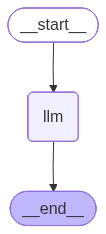

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
config = {"configurable": {"thread_id": "conversation_1"}}

In [7]:
from langchain_core.messages import HumanMessage

result = graph.invoke({"messages": [HumanMessage(content="내 이름은 김일남이야.")]}, config=config)

In [8]:
result

{'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='안녕하세요, 김일남 님. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-8f32-7b83-9215-d6cc33ceb588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 494, 'total_tokens': 503, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 484}})]}

In [9]:
state_history = graph.get_state_history(config=config)

In [10]:
state_history

<generator object Pregel.get_state_history at 0x000001B840EBF5E0>

In [11]:
next(state_history)

StateSnapshot(values={'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}), AIMessage(content='안녕하세요, 김일남 님. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-8f32-7b83-9215-d6cc33ceb588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 494, 'total_tokens': 503, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 484}})]}, next=(), config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb8d-c499-62a2-8001-deacb297d269'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-02-22T06:36:46.940432+00:00', parent_config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb8d-a5a2-68ec-8000-484e42369f0c'}}, tasks=(), interrupts=())

In [12]:
next(state_history)

StateSnapshot(values={'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={})]}, next=('llm',), config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb8d-a5a2-68ec-8000-484e42369f0c'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-02-22T06:36:43.693694+00:00', parent_config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb8d-a599-6ed4-bfff-5a04f7de6da6'}}, tasks=(PregelTask(id='fd6e79ca-dd93-1ac4-6f3a-36997520aa82', name='llm', path=('__pregel_pull', 'llm'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='안녕하세요, 김일남 님. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-8f32-7b83-9215-d6cc33ceb588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens':

In [13]:
next(state_history)

StateSnapshot(values={'messages': []}, next=('__start__',), config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb8d-a599-6ed4-bfff-5a04f7de6da6'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-02-22T06:36:43.690158+00:00', parent_config=None, tasks=(PregelTask(id='588e4a3a-9db1-7adc-de85-77a2f453e0c3', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={})]}),), interrupts=())

In [14]:
state_history = graph.get_state_history(config=config)

In [15]:
lst = list(state_history)

In [16]:
lst

[StateSnapshot(values={'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}), AIMessage(content='안녕하세요, 김일남 님. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-8f32-7b83-9215-d6cc33ceb588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 494, 'total_tokens': 503, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 484}})]}, next=(), config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb8d-c499-62a2-8001-deacb297d269'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-02-22T06:36:46.940432+00:00', parent_config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb8d-a5a2-68ec-8000-484e42369f0c'}}, tasks=(), interrupts=()),
 StateSn

In [17]:
lst[-1]

StateSnapshot(values={'messages': []}, next=('__start__',), config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb8d-a599-6ed4-bfff-5a04f7de6da6'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-02-22T06:36:43.690158+00:00', parent_config=None, tasks=(PregelTask(id='588e4a3a-9db1-7adc-de85-77a2f453e0c3', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={})]}),), interrupts=())

In [18]:
graph.invoke({"messages": [HumanMessage(content="대한민국의 수도는?")]}, config=config)

{'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='안녕하세요, 김일남 님. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-8f32-7b83-9215-d6cc33ceb588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 494, 'total_tokens': 503, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 484}}),
  HumanMessage(content='대한민국의 수도는?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='대한민국의 수도는 **서울**입니다.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-9c8f-70e2-9cf0-eb1374d2f944-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 27, 'output_tokens': 10, 'total_tokens':

In [19]:
graph.update_state(
    config=config,
    values={"messages": [HumanMessage(content="그 도시의 관광명소를 알려주세요.")]}
)

{'configurable': {'thread_id': 'conversation_1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f10fb92-14af-60bc-8005-0186c3706356'}}

In [20]:
result = graph.invoke({"messages": []}, config=config)

In [21]:
result

{'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='안녕하세요, 김일남 님. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-8f32-7b83-9215-d6cc33ceb588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 494, 'total_tokens': 503, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 484}}),
  HumanMessage(content='대한민국의 수도는?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='대한민국의 수도는 **서울**입니다.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-9c8f-70e2-9cf0-eb1374d2f944-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 27, 'output_tokens': 10, 'total_tokens':

In [22]:
history = list(graph.get_state_history(config))

In [23]:
history

[StateSnapshot(values={'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}), AIMessage(content='안녕하세요, 김일남 님. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-8f32-7b83-9215-d6cc33ceb588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 494, 'total_tokens': 503, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 484}}), HumanMessage(content='대한민국의 수도는?', additional_kwargs={}, response_metadata={}), AIMessage(content='대한민국의 수도는 **서울**입니다.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-9c8f-70e2-9cf0-eb1374d2f944-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 27, 'output_tokens': 10,

In [53]:
for i, snapshot in enumerate(history):
    print(f"{i}. Step {snapshot.metadata.get('step', '')}")
    print(f"   Checkpoint ID: {snapshot.config['configurable']['checkpoint_id']}")
    print(f"   Next nodes: {snapshot.next}")

0. Step 8
   Checkpoint ID: 1f10fb94-795a-67b1-8008-7e605fdeb60f
   Next nodes: ()
1. Step 7
   Checkpoint ID: 1f10fb94-063f-6eff-8007-a2819c903760
   Next nodes: ('llm',)
2. Step 6
   Checkpoint ID: 1f10fb94-063d-6828-8006-317153fc2f49
   Next nodes: ('__start__',)
3. Step 5
   Checkpoint ID: 1f10fb92-14af-60bc-8005-0186c3706356
   Next nodes: ()
4. Step 4
   Checkpoint ID: 1f10fb8d-ce7d-6098-8004-b0d524fef60e
   Next nodes: ()
5. Step 3
   Checkpoint ID: 1f10fb8d-c645-6834-8003-45fc06c8f21d
   Next nodes: ('llm',)
6. Step 2
   Checkpoint ID: 1f10fb8d-c640-6a21-8002-f9d6e7ff9822
   Next nodes: ('__start__',)
7. Step 1
   Checkpoint ID: 1f10fb8d-c499-62a2-8001-deacb297d269
   Next nodes: ()
8. Step 0
   Checkpoint ID: 1f10fb8d-a5a2-68ec-8000-484e42369f0c
   Next nodes: ('llm',)
9. Step -1
   Checkpoint ID: 1f10fb8d-a599-6ed4-bfff-5a04f7de6da6
   Next nodes: ('__start__',)


In [60]:
target_snapshot = None

for snapshot in history:
    if snapshot.config['configurable']['checkpoint_id'] == "1f10fb8d-c645-6834-8003-45fc06c8f21d":
        target_snapshot = snapshot
        break

In [61]:
target_snapshot

StateSnapshot(values={'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}), AIMessage(content='안녕하세요, 김일남 님. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-8f32-7b83-9215-d6cc33ceb588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 494, 'total_tokens': 503, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 484}}), HumanMessage(content='대한민국의 수도는?', additional_kwargs={}, response_metadata={})]}, next=('llm',), config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb8d-c645-6834-8003-45fc06c8f21d'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-02-22T06:36:47.115883+00:00', parent_config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpo

In [62]:
target_snapshot.config

{'configurable': {'thread_id': 'conversation_1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f10fb8d-c645-6834-8003-45fc06c8f21d'}}

In [63]:
graph.update_state(
    config=target_snapshot.config,
    values={"messages": ["그 지역에 서울대학교가 있나요?"]},
)

{'configurable': {'thread_id': 'conversation_1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f10fbe7-3da2-65e0-8004-099bfc708ca1'}}

In [64]:
result = graph.invoke({"messages": []}, config=config)

In [65]:
result["messages"][-1].content

'네, 대한민국의 수도는 **서울**입니다.\n\n그리고 **서울대학교는 이름 그대로 서울에 위치하고 있습니다.** 주 캠퍼스는 서울특별시 관악구에 있습니다.'

In [66]:
result

{'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='안녕하세요, 김일남 님. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8410-8f32-7b83-9215-d6cc33ceb588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 494, 'total_tokens': 503, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 484}}),
  HumanMessage(content='대한민국의 수도는?', additional_kwargs={}, response_metadata={}),
  '그 지역에 서울대학교가 있나요?',
  AIMessage(content='네, 대한민국의 수도는 **서울**입니다.\n\n그리고 **서울대학교는 이름 그대로 서울에 위치하고 있습니다.** 주 캠퍼스는 서울특별시 관악구에 있습니다.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8435-517d-7851-a5ac-5352ce3e6ec2-0', tool_calls=[], inval